<a href="https://colab.research.google.com/github/geovannadiasbaldoino/diabetes-screening-nn/blob/main/Supervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# 0. CARREGAMENTO ONLINE E TRATAMENTO DO DATASET (Diabetes)
# ==============================================================================
import os
import kagglehub
import pandas as pd
import numpy as np

# Download do dataset
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
csv_path = os.path.join(path, "diabetes.csv")

# Criar o DataFrame
df = pd.read_csv(csv_path)

# Renomear colunas para snake_case
df = df.rename(columns={
    'Pregnancies': 'pregnancies',
    'Glucose': 'glucose',
    'BloodPressure': 'blood_pressure',
    'SkinThickness': 'skin_thickness',
    'Insulin': 'insulin',
    'BMI': 'bmi',
    'DiabetesPedigreeFunction': 'diabetes_pedigree_function',
    'Age': 'age',
    'Outcome': 'target'
})

print("Formato do Dataset (Shape):", df.shape)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Formato do Dataset (Shape): (768, 9)


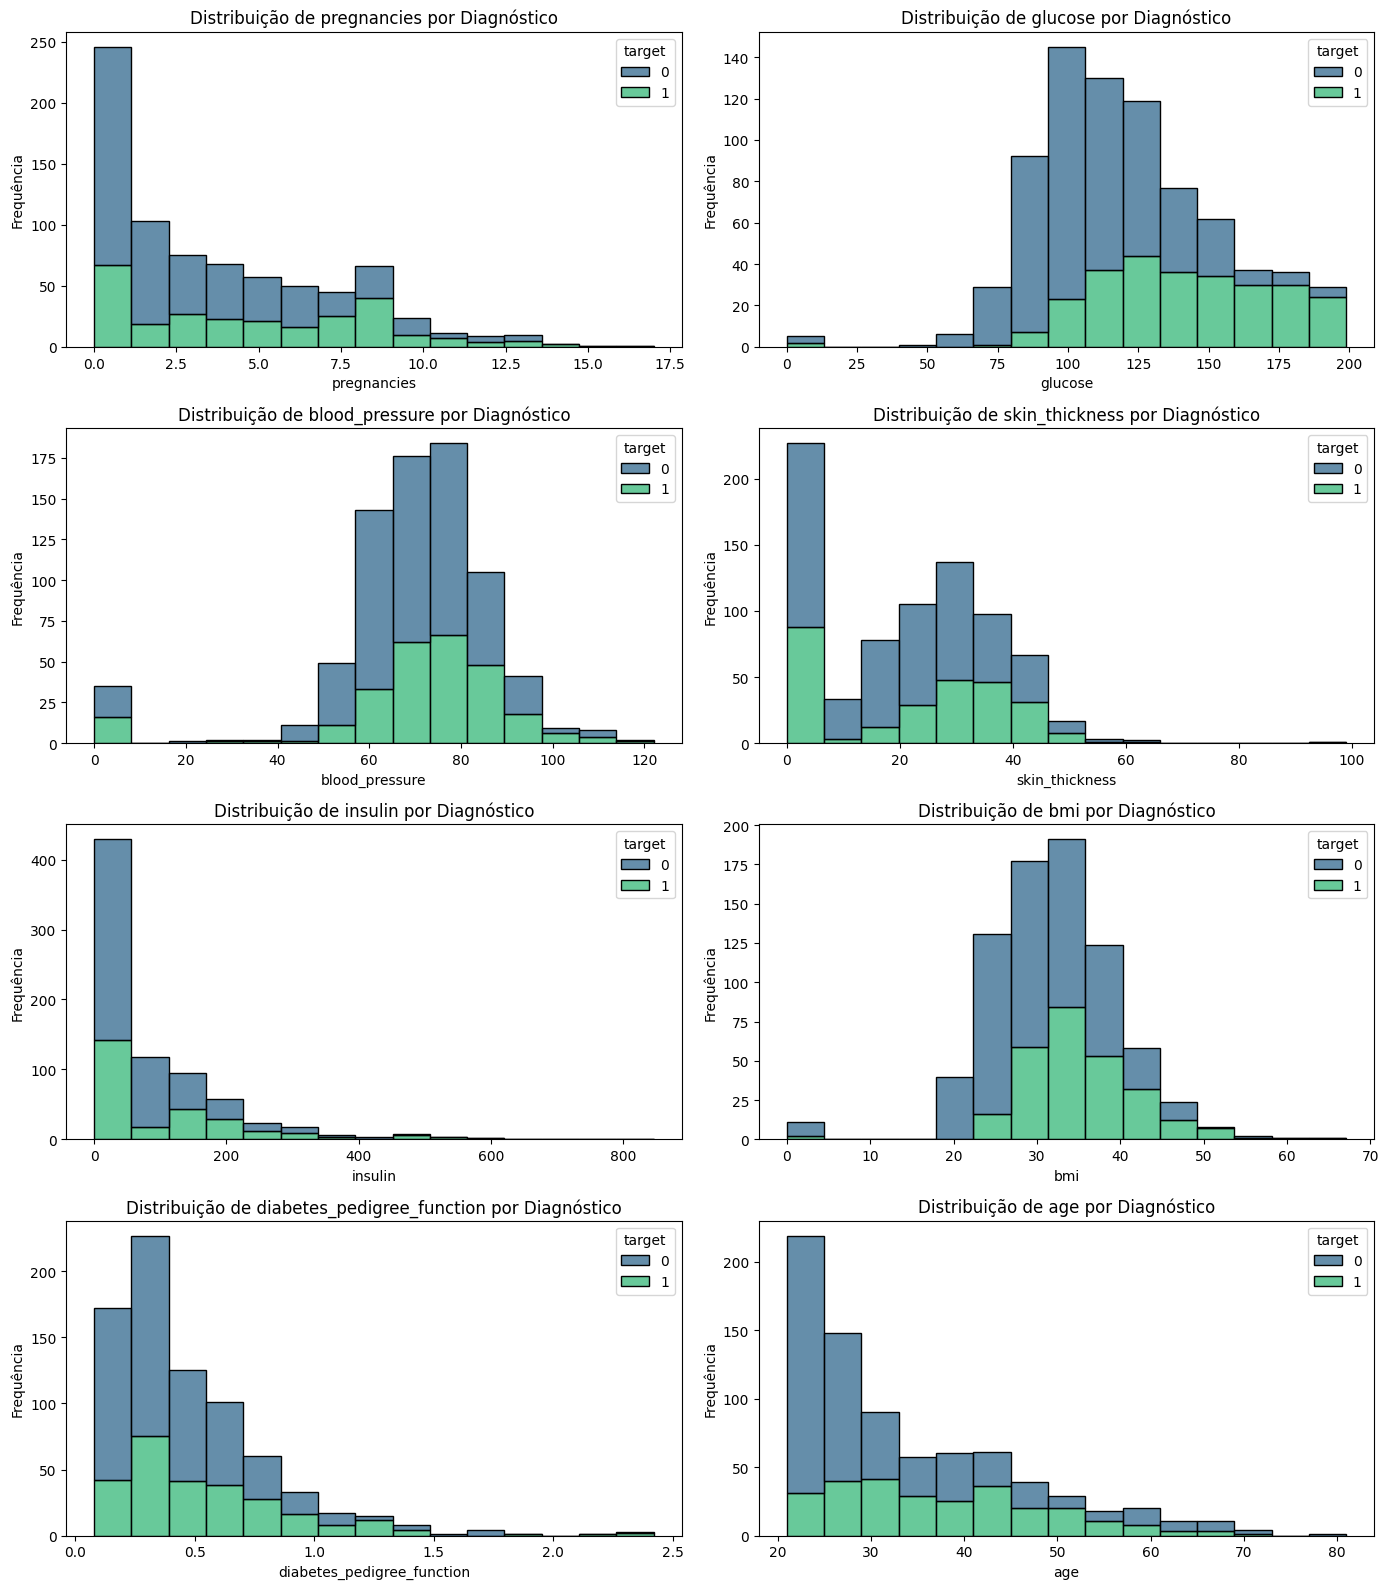

In [ ]:
# ==============================================================================
# 1. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness',
                    'insulin', 'bmi', 'diabetes_pedigree_function', 'age']

# Distribuição estratificada pelo diagnóstico real
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    if i < len(axes):
        sns.histplot(data=df, x=col, hue='target', multiple='stack', ax=axes[i], bins=15, palette='viridis')
        axes[i].set_title(f'Distribuição de {col} por Diagnóstico')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 2. DIVISÃO DOS DADOS E PADRONIZAÇÃO (A grande correção!)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separando preditores (X) e a resposta (y)
X_raw = df[features_to_plot]
y = df['target']

# Divisão 80/20 mantendo a proporção original de diabéticas (stratify)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

# Aplicando o StandardScaler para equilibrar as escalas das variáveis médicas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"\nDados de Treino prontos: {X_train.shape}")
print(f"Dados de Teste prontos: {X_test.shape}")


Dados de Treino prontos: (614, 8)
Dados de Teste prontos: (154, 8)


In [ ]:
# ==============================================================================
# 3. CONSTRUÇÃO DA REDE NEURAL (Ajustada para classificação binária)
# ==============================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    # Camada de entrada (8 atributos) + 1ª Oculta
    Dense(5, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.1), # Proteção extra contra overfitting
    # 2ª Camada Oculta
    Dense(3, activation='relu'),
    # Saída Binária: 1 neurônio (Sigmoid) que cospe a probabilidade de ter diabetes (0 a 1)
    Dense(1, activation='sigmoid')
])

meu_otimizador = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compilação usando métricas específicas para avaliar o cenário médico
model.compile(
    optimizer=meu_otimizador,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================================================================
# 4. TREINAMENTO DO MODELO
# ==============================================================================
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=16,
    verbose=1,
    validation_data=(X_test, y_test)
)

print("\n" + "="*50 + "\n")

# Avaliação final no conjunto de Treino
loss_train, acc_train, prec_train, rec_train = model.evaluate(X_train, y_train, verbose=0)
print(f"Métricas de Treino -> Acurácia: {acc_train:.4f} | Precisão: {prec_train:.4f} | Recall: {rec_train:.4f}")

# Avaliação final no conjunto de Teste (Dados Inéditos)
loss_test, acc_test, prec_test, rec_test = model.evaluate(X_test, y_test, verbose=0)
print(f"Métricas de Teste  -> Acurácia: {acc_test:.4f} | Precisão: {prec_test:.4f} | Recall: {rec_test:.4f}")

Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4430 - loss: 0.7048 - precision: 0.3571 - recall: 0.7477 - val_accuracy: 0.4805 - val_loss: 0.7114 - val_precision: 0.3725 - val_recall: 0.7037
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5668 - loss: 0.6923 - precision: 0.4207 - recall: 0.6449 - val_accuracy: 0.5390 - val_loss: 0.7004 - val_precision: 0.3803 - val_recall: 0.5000
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6417 - loss: 0.6805 - precision: 0.4868 - recall: 0.5187 - val_accuracy: 0.6234 - val_loss: 0.6913 - val_precision: 0.4630 - val_recall: 0.4630
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6726 - loss: 0.6764 - precision: 0.5389 - recall: 0.4206 - val_accuracy: 0.6494 - val_loss: 0.6853 - val_precision: 0.5000 - val_recall: 0.4630
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6824 - loss: 0.6687 - precision: 0.5748 - recall: 0.3411 - val_accuracy: 0.6818 - val_loss: 0.6787

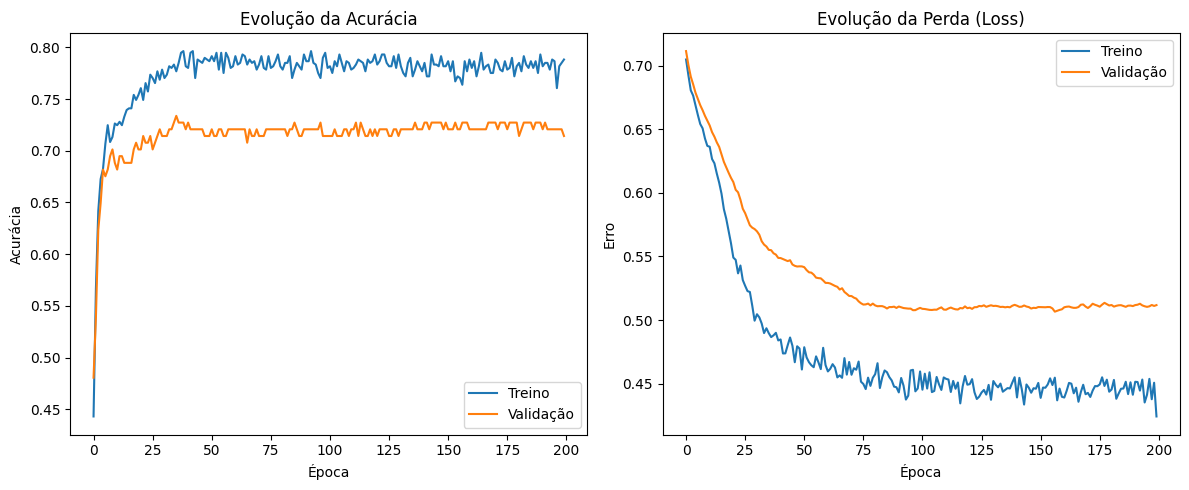

In [ ]:
# ==============================================================================
# 5. GRÁFICOS DE DESEMPENHO (Histórico de Aprendizado)
# ==============================================================================
plt.figure(figsize=(12, 5))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Evolução da Acurácia')
plt.ylabel('Acurácia')
plt.xlabel('Época')
plt.legend()

# Gráfico de Erro (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Evolução da Perda (Loss)')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


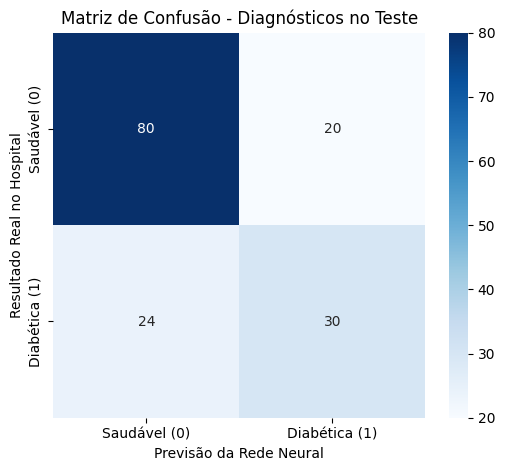


--- Relatório de Classificação Detalhado ---
               precision    recall  f1-score   support

 Saudável (0)       0.77      0.80      0.78       100
Diabética (1)       0.60      0.56      0.58        54

     accuracy                           0.71       154
    macro avg       0.68      0.68      0.68       154
 weighted avg       0.71      0.71      0.71       154



In [ ]:
# ==============================================================================
# 6. MÉTRICA DE SAÚDE REAL: MATRIZ DE CONFUSÃO
# ==============================================================================
from sklearn.metrics import confusion_matrix, classification_report

# Previsões da rede (em probabilidades de 0 a 1)
y_pred_prob = model.predict(X_test)
# Se a probabilidade for maior que 0.5, classifica como Diabética (1), senão Saudável (0)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Diabética (1)'],
            yticklabels=['Saudável (0)', 'Diabética (1)'])
plt.title('Matriz de Confusão - Diagnósticos no Teste')
plt.ylabel('Resultado Real no Hospital')
plt.xlabel('Previsão da Rede Neural')
plt.show()

print("\n--- Relatório de Classificação Detalhado ---")
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Diabética (1)']))